# **MÓDULO 39 - Exercicio - Aplicando SVM**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros. A mesma que também usamos na tarefa de XGboost!


In [1]:
from sklearn.svm import SVC
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.discriminant_analysis import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [2]:
# IMPORTAÇÃO DE DADOS

df = pd.read_csv("CARRO_CLIENTES.csv")

In [3]:
# VERIFICANDO TIPOS DE DADOS

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [4]:
# ESPECIFICANDO TIPO DE VARIÁVEL 

df["Gender"] = df["Gender"].astype("string")

In [5]:
# VERIFICANDO DADOS NULOS

df.isnull().mean() * 100

User ID         0.0
Gender          0.0
Age             0.0
AnnualSalary    0.0
Purchased       0.0
dtype: float64

In [6]:
# PADRONIZAÇÃO DE NOME DAS COLUNAS

df.columns = df.columns.str.upper()
df.columns = df.columns.str.replace(" ", "_")
df = df.rename(columns={"ANNUALSALARY": "ANNUAL_SALARY"})
df['GENDER'] = df['GENDER'].str.upper() 

In [7]:
# VERIFICAÇÃO DE ERROS DE DIGITAÇÃO 

df['GENDER'].value_counts()

GENDER
FEMALE    516
MALE      484
Name: count, dtype: Int64

In [8]:
# ELIMINANDO COLUNA DESNECESSÁRIA

df = df.drop(columns='USER_ID')

In [9]:
# PRÉVIA

df.head(3)

,GENDER,AGE,ANNUAL_SALARY,PURCHASED
0,MALE,35,20000,0
1,MALE,40,43500,0
2,MALE,49,74000,0


# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [10]:
# APLICAÇÃO DO LABEL ENCODER

label_encoder = LabelEncoder()
df['GENDER'] = label_encoder.fit_transform(df['GENDER'])

In [11]:
# PRÉVIA

df.head(3)

,GENDER,AGE,ANNUAL_SALARY,PURCHASED
0,1,35,20000,0
1,1,40,43500,0
2,1,49,74000,0


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

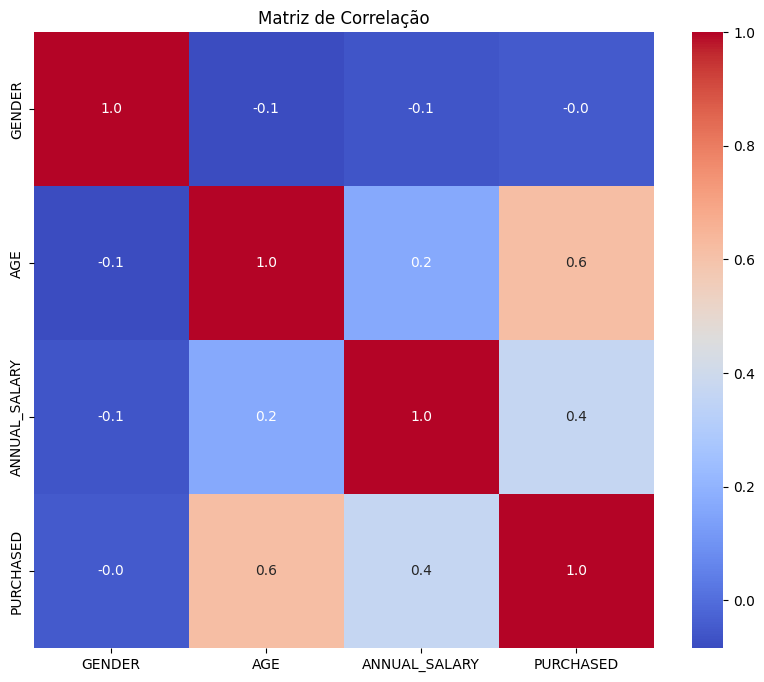

In [12]:
# MATRIZ DE CORRELAÇÃO

correlation_matrix = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".1f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [13]:
# SEPARAÇÃO DE BASE TESTE E TRENO

X_train, X_test, Y_train, Y_test = train_test_split(
    df.drop('PURCHASED', axis=1),
    df['PURCHASED'],
    test_size=0.25,
    random_state=0
)

In [14]:
# PADRONIZAÇÃO DE DADOS

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Todos passos até aqui vocês realizaram na tarefa anterior também!**

# 5. Treino o modelo SVM com sua base de treino.
Esse modelo deve ser treinado usando o kernel linear.

In [15]:
# TREINAMENTO DO SVM LINEAR

svm_model_linear = SVC(kernel='linear', random_state=0)
svm_model_linear.fit(X_train_scaled, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [16]:
# APLICAÇÃO DO SVM LINEAR NAS VARIÁVEIS DE TREINO + MÉTRICAS DE TREINO

Y_pred_treino_linear = svm_model_linear.predict(X_train_scaled)
report_treino_linear = classification_report(Y_train, Y_pred_treino_linear)

print(report_treino_linear)

              precision    recall  f1-score   support

           0       0.80      0.91      0.85       446
           1       0.83      0.68      0.75       304

    accuracy                           0.81       750
   macro avg       0.82      0.79      0.80       750
weighted avg       0.82      0.81      0.81       750



# 6. Realize as previsões para a base de teste e traga a avaliação.

In [17]:
# APLICAÇÃO DO SVM LINEAR NAS VARIÁVEIS DE TESTE + MÉTRICAS DE TESTE

Y_pred_teste_linear = svm_model_linear.predict(X_test_scaled)
report_teste_linear = classification_report(Y_test, Y_pred_teste_linear)

print(report_teste_linear)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       152
           1       0.85      0.72      0.78        98

    accuracy                           0.84       250
   macro avg       0.84      0.82      0.83       250
weighted avg       0.84      0.84      0.84       250



# 7. Treine um novo modelo SVM com sua base de treino + realize as previsões e avalições.
Esse modelo dedve ser treinado usando o kernel poly.

In [18]:
# TREINAMENTO DO SVM POLINOMIAL

svm_model_poly = SVC(kernel='poly', random_state=0)
svm_model_poly.fit(X_train_scaled, Y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [19]:
# APLICAÇÃO DO SVM POLINOMIAL NAS VARIÁVEIS DE TREINO + MÉTRICAS DE TREINO

Y_pred_treino_poly = svm_model_poly.predict(X_train_scaled)
report_treino_poly = classification_report(Y_train, Y_pred_treino_poly)

print(report_treino_poly)

              precision    recall  f1-score   support

           0       0.83      0.92      0.87       446
           1       0.86      0.71      0.78       304

    accuracy                           0.84       750
   macro avg       0.84      0.82      0.83       750
weighted avg       0.84      0.84      0.83       750



In [20]:
# APLICAÇÃO DO SVM POLINOMIAL NAS VARIÁVEIS DE TESTE + MÉTRICAS DE TESTE

Y_pred_teste_poly = svm_model_poly.predict(X_test_scaled)
report_teste_poly = classification_report(Y_test, Y_pred_teste_poly)

print(report_teste_poly)

              precision    recall  f1-score   support

           0       0.85      0.94      0.89       152
           1       0.89      0.73      0.80        98

    accuracy                           0.86       250
   macro avg       0.87      0.84      0.85       250
weighted avg       0.86      0.86      0.86       250



# 8. Qual modelo se saiu melhor? O SVM com kernel linear ou poly? Compare também com o XGboost, da atividade anterior, você obteve melhores previsões com qual dos modelos?

In [21]:
# COMPARAÇÃO ENTRE KERNEL LINEAR E POLY

print("REPORT - KERNEL LINEAR")
print(report_teste_linear)

print("\nREPORT - KERNEL POLY")
print(report_teste_poly)

REPORT - KERNEL LINEAR
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       152
           1       0.85      0.72      0.78        98

    accuracy                           0.84       250
   macro avg       0.84      0.82      0.83       250
weighted avg       0.84      0.84      0.84       250


REPORT - KERNEL POLY
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       152
           1       0.89      0.73      0.80        98

    accuracy                           0.86       250
   macro avg       0.87      0.84      0.85       250
weighted avg       0.86      0.86      0.86       250



**ANÁLISE:** A partir do classification report, temos que o modelo com kernel **poly** obteve melhores resultados em *todas* as métricas analisadas. Portanto, pode-se concluir que o melhor modelo entre os dois foi o poly. 

Além disso, relembrando o resultado da tarefa anterior:

```plain text
RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       152
           1       0.90      0.83      0.86        98

    accuracy                           0.90       250
   macro avg       0.90      0.88      0.89       250
weighted avg       0.90      0.90      0.90       250
```

Podemos notar que o XGboost obteve valores melhores em todas as métricas, adequando-se de maneira melhor para essa base de dados.

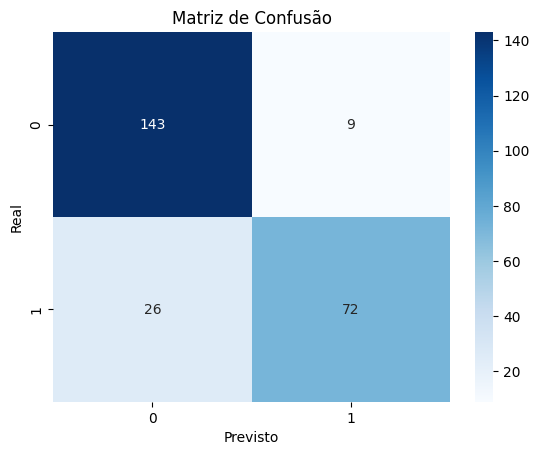

In [22]:
# APRESENTAÇÃO DE MATRIZ DE CONFUSÃO DO MELHOR MODELO (POLY)

cm = confusion_matrix(Y_test, Y_pred_teste_poly)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

## Extra: balanceamento e ajustes de hiperparâmetro

In [23]:
# BALANCEAMENTO

smote = SMOTE(random_state=0)
X_train_balanced, Y_train_balanced = smote.fit_resample(X_train_scaled, Y_train)

In [24]:
# CRIAÇÃO DO MODELO ALTERNATIVO COM GRIDSEARCH

svm_model_alt = SVC()

param_distributions = {
    "C": [0.01, 0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly", "sigmoid"],
    "degree": [2, 3, 4, 5, 6]
}

grid = GridSearchCV(
    svm_model_alt,
    param_grid=param_distributions,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid.fit(X_train_balanced, Y_train_balanced)
best_model = grid.best_estimator_
print(grid.best_params_)

{'C': 100, 'degree': 2, 'kernel': 'rbf'}


In [25]:
# APLICAÇÃO DO SVM OTIMIZADO NAS VARIÁVEIS DE TREINO + MÉTRICAS DE TREINO

Y_pred_alt_treino = best_model.predict(X_train_balanced)
print(classification_report(Y_train_balanced, Y_pred_alt_treino))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93       446
           1       0.92      0.94      0.93       446

    accuracy                           0.93       892
   macro avg       0.93      0.93      0.93       892
weighted avg       0.93      0.93      0.93       892



In [26]:
# APLICAÇÃO DO SVM OTIMIZADO NAS VARIÁVEIS DE TESTE + MÉTRICAS DE TESTE

Y_pred_alt_teste = best_model.predict(X_test_scaled)
print(classification_report(Y_test, Y_pred_alt_teste))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       152
           1       0.88      0.91      0.89        98

    accuracy                           0.92       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.92      0.92      0.92       250



In [27]:
# COMPARAÇÃO ENTRE O MODELO POLY COM O MODELO OTIMIZADO

print("REPORT - KERNEL POLY")
print(report_teste_poly)

print("REPORT - MODELO OTIMIZADO")
print(classification_report(Y_test, Y_pred_alt_teste))

REPORT - KERNEL POLY
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       152
           1       0.89      0.73      0.80        98

    accuracy                           0.86       250
   macro avg       0.87      0.84      0.85       250
weighted avg       0.86      0.86      0.86       250

REPORT - MODELO OTIMIZADO
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       152
           1       0.88      0.91      0.89        98

    accuracy                           0.92       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.92      0.92      0.92       250



**ANÁLISE:** A partir da comparação do report, podemos perceber que houve um aumento considerável em todas as métricas com excessão da *recall* classe 0 (que diminuiu dois pnts) e na *precision* de classe 1 (que diminuiu 1 pnt). Nas demais, obtivemos aumento médio acima de 5 pontos com destaque ao *recall* da classe 1 com aumento de 18pnts.

Vale destacar também que o modelo SVM otimizado obteve melhores métricas ao ser comparado com o modelo XGBoost apresentado abaixo:

```plain text
RELATÓRIO DE CLASSIFICAÇÃO:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       152
           1       0.90      0.83      0.86        98

    accuracy                           0.90       250
   macro avg       0.90      0.88      0.89       250
weighted avg       0.90      0.90      0.90       250
```
